# QRank long-tail analysis of the EL gold standard

This notebook measures how 'popular' the Wikidata entities in our entity-linking gold standard are, using the [QRank](https://qrank.toolforge.org/) pageview-based popularity score.

QRank aggregates Wikipedia pageview counts into a single popularity score per Wikidata entity. Entities that **do not appear** in the QRank dump have no recorded pageviews — the most long-tail end of the distribution — and are scored `0` here.

**Goal:** see how long-tail the entities in the 1816 travelogue gold standard are. The set of ~50 unique Wikidata QIDs annotated in `entity_linking/1816_el_gs.csv` is matched against the QRank dump in `qrank/qrank.csv` (~400 MB, 28.7 M rows). Only Wikidata QIDs are matched (GeoNames-only and `NIL` annotations are reported separately). The gold-standard entity **spans** (text + label) are kept alongside the scores, and each matched QID is enriched with its **Wikidata label** (Dutch preferred).

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# locate qrank.csv by walking up from the cwd (notebooks have no __file__)
here = Path.cwd()
QRANK_DIR = next((p for p in [here, *here.parents] if (p / 'qrank.csv').exists()), None)
if QRANK_DIR is None:
    raise FileNotFoundError('qrank.csv not found under cwd or its parents')
EL_DIR = QRANK_DIR.parent                       # entity_linking/
GS_CSV = EL_DIR / '1816_el_gs.csv'
QRANK_CSV = QRANK_DIR / 'qrank.csv'
print('Gold standard:', GS_CSV, GS_CSV.exists())
print('QRank dump   :', QRANK_CSV, QRANK_CSV.exists())

Gold standard: /home/tijn-do/hist-dutch-travelogues-nlp/entity_linking/1816_el_gs.csv True
QRank dump   : /home/tijn-do/hist-dutch-travelogues-nlp/entity_linking/qrank/qrank.csv True


## 1. Load the gold standard

Read with `pandas` (handles the quoted fields that contain commas). Keep only rows that carry a valid Wikidata QID (`Q` followed by digits). `NIL` and GeoNames-only annotations are counted but excluded from the QRank match.

In [31]:
gs = pd.read_csv(GS_CSV, dtype=str).fillna('')
print(f'Total gold annotations        : {len(gs)}')
print(f"  with a wikidata_qid value    : {(gs['wikidata_qid'] != '').sum()}")
print(f"  NIL (no link)               : {(gs['wikidata_qid'] == 'NIL').sum()}")
print(f'  valid Wikidata QIDs (Q[0-9]+): {gs.wikidata_qid.str.match(r"^Q[0-9]+$").sum()}')

# keep entity spans + a valid-QID mask
gs_qid = gs[gs.wikidata_qid.str.match(r'^Q[0-9]+$')].copy()
print(f'\nAnnotations to match against QRank: {len(gs_qid)}')
print(f'Unique QIDs                         : {gs_qid.wikidata_qid.nunique()}')
gs_qid.head()

Total gold annotations        : 315
  with a wikidata_qid value    : 168
  NIL (no link)               : 75
  valid Wikidata QIDs (Q[0-9]+): 93

Annotations to match against QRank: 93
Unique QIDs                         : 46


,text,label,start_char,end_char,wikidata_qid,geonames_id,note
1,Cassel,E53_Place,21,27,Q2865,2892518,
4,Paderborn,E53_Place,119,128,Q2971,2855745,
7,Warburg,E53_Place,210,217,Q968,2814153,
10,Paderborn,E53_Place,314,323,Q2971,2855745,
11,Cassel,E53_Place,404,410,Q2865,2892518,


## 2. Single streaming pass over the QRank dump

The dump is ~400 MB / 28.7 M rows and **sorted descending by QRank**, so row position equals popularity rank (rank 1 = most-viewed entity on Wikidata). We stream it once in chunks (flat memory) and do three things in that one pass:

* `hits`     — QID → QRank (for the tables)
* `gs_match` — QID → (rank, QRank) (for plotting GS points on the curve)
* `curve`    — **log-spaced** sample of (rank, QRank) points, ~3k of them, spaced at log10 intervals so they cover the head (rank 1, 2, …) as well as the tail. (Plain linear sampling — every Nth row — leaves the left ~half of a log plot empty, because the head is tiny in rank-count terms.)

Expect ~1–2 minutes.

In [32]:
# Log-spaced sampling: target ranks at log10 intervals so the sampled points
# spread evenly across a log popularity axis AND cover the head (rank 1, 2, ...),
# not just every 10,000th row (which on a log axis leaves the left ~half empty).
# Targets are 1-based ranks from 1 up to ~31.6M (log10 7.5); any beyond N_total
# simply never get hit, which is harmless.
SAMPLE_TARGETS = np.unique(np.round(np.logspace(0, 7.5, 3000)).astype(np.int64))
needed = set(gs_qid.wikidata_qid)
print(f'Streaming {QRANK_CSV.name} once ({len(needed)} GS QIDs to locate) ...')

hits, gs_match = {}, {}            # qid -> qrank ; qid -> (rank, qrank)
curve_rank, curve_qrank = [], []  # log-spaced (rank, qrank) sample points
sample_ptr = 0
row = 0
reader = pd.read_csv(QRANK_CSV, dtype={'Entity': str, 'QRank': 'Int64'},
                     chunksize=1_000_000)
for chunk in reader:
    ents = chunk.Entity.values
    ranks = np.asarray(chunk.QRank.values, dtype=np.int64)
    n = len(chunk)
    start_gr = row + 1                              # first global rank in this chunk (1-based)
    end_gr = row + n                                # last global rank in this chunk
    # collect every log-spaced target that falls inside this chunk's rank range
    while sample_ptr < len(SAMPLE_TARGETS) and SAMPLE_TARGETS[sample_ptr] <= end_gr:
        tgt = int(SAMPLE_TARGETS[sample_ptr])
        if tgt >= start_gr:
            li = tgt - start_gr
            curve_rank.append(tgt)
            curve_qrank.append(int(ranks[li]))
        sample_ptr += 1
    # GS matching: locate needed QIDs wherever they appear in the chunk
    global_row = start_gr + np.arange(n)            # 1-based popularity rank per row
    mask = chunk.Entity.isin(needed).values
    if mask.any():
        for q, r, gr in zip(ents[mask], ranks[mask], global_row[mask]):
            hits[q] = int(r)
            gs_match[q] = (int(gr), int(r))
    row += n
    if row % 10_000_000 == 0:
        print(f'  scanned {row:,} rows, {len(hits)}/{len(needed)} GS QIDs located')

N_total = row
curve_rank = np.array(curve_rank, dtype=np.int64)
curve_qrank = np.array(curve_qrank, dtype=np.int64)
print(f'\nTotal entities in dump : {N_total:,}')
print(f'Curve sample points    : {len(curve_rank):,}  '
      f'(log-spaced, ranks {curve_rank.min()}..{curve_rank.max():,})')
print(f'GS QIDs located in dump : {len(hits)} / {len(needed)} '
      f'({len(needed)-len(hits)} not in QRank = most long-tail)')
missing = needed - set(hits)
if missing:
    print('  ', sorted(missing))

Streaming qrank.csv once (46 GS QIDs to locate) ...
  scanned 10,000,000 rows, 42/46 GS QIDs located
  scanned 20,000,000 rows, 43/46 GS QIDs located

Total entities in dump : 28,691,759
Curve sample points    : 2,260  (log-spaced, ranks 1..28,673,838)
GS QIDs located in dump : 44 / 46 (2 not in QRank = most long-tail)
   ['Q100509241', 'Q63039258']


### 2b. Fetch Wikidata labels (matched QIDs only)

The QRank dump carries only QIDs and scores, not labels. For each QID that **matched** in QRank we fetch its Wikidata label (Dutch preferred, English fallback) via the `wbgetentities` API. QIDs not in QRank get no label (empty). Result is cached to `qid_labels.json` so re-runs don't re-hit the API.

In [33]:
import json, urllib.parse, urllib.request, time

LABELS_CACHE = QRANK_DIR / 'qid_labels.json'

def fetch_wikidata_labels(qids, langs=('nl', 'en')):
    """Return {qid: label} via wbgetentities (max 50 ids/call). nl preferred, else en."""
    out = {}
    qids = list(qids)
    for i in range(0, len(qids), 50):
        batch = qids[i:i+50]
        params = urllib.parse.urlencode({
            'action': 'wbgetentities', 'ids': '|'.join(batch),
            'props': 'labels', 'languages': '|'.join(langs), 'format': 'json',
        })
        url = 'https://www.wikidata.org/w/api.php?' + params
        req = urllib.request.Request(url, headers={'User-Agent': 'hist-dutch-travelogues-nlp/1.0 (research)'})
        with urllib.request.urlopen(req, timeout=60) as r:
            data = json.load(r)
        for qid, ent in data.get('entities', {}).items():
            labs = ent.get('labels', {})
            for L in langs:
                if L in labs:
                    out[qid] = labs[L]['value']
                    break
        time.sleep(0.5)   # be nice to the API
    return out

matched_qids = sorted(hits)               # only QIDs present in QRank
labels = {}
if LABELS_CACHE.exists():
    labels = json.load(open(LABELS_CACHE))
    print(f'Loaded {len(labels)} cached labels from {LABELS_CACHE.name}')

to_fetch = [q for q in matched_qids if q not in labels]
if to_fetch:
    print(f'Fetching {len(to_fetch)} labels from Wikidata ...')
    new = fetch_wikidata_labels(to_fetch)
    labels.update(new)
    json.dump(labels, open(LABELS_CACHE, 'w'), ensure_ascii=False, indent=2)
    print(f'  got {len(new)}, saved to {LABELS_CACHE.name}')

labels = {q: labels[q] for q in matched_qids if q in labels}   # keep matched-only
print(f'\nLabels available for {len(labels)}/{len(matched_qids)} matched QIDs.')
missing_lbl = set(matched_qids) - set(labels)
if missing_lbl:
    print('  no label found for:', sorted(missing_lbl))

Loaded 42 cached labels from qid_labels.json
Fetching 2 labels from Wikidata ...
  got 0, saved to qid_labels.json

Labels available for 42/44 matched QIDs.
  no label found for: ['Q117323794', 'Q1902237']


## 3. Per-annotation table

Keep the entity span (`text`, `label`) and attach its QRank and Wikidata label. QIDs absent from the dump get `QRank = 0` and no label (longest tail).

In [34]:
gs_qid['QRank'] = gs_qid.wikidata_qid.map(hits).fillna(0).astype('Int64')
gs_qid['in_qrank'] = gs_qid.wikidata_qid.isin(hits)
gs_qid['wikidata_label'] = gs_qid.wikidata_qid.map(labels).fillna('')   # only matched QIDs

cols = ['text', 'label', 'wikidata_qid', 'wikidata_label', 'geonames_id', 'QRank', 'in_qrank']
out = gs_qid[cols].copy().sort_values('QRank', ascending=False)
out.to_csv(QRANK_DIR / '1816_qrank_matched.csv', index=False)
print(f'Wrote {len(out)} annotations -> {QRANK_DIR / "1816_qrank_matched.csv"}')
out.head(20)

Wrote 93 annotations -> /home/tijn-do/hist-dutch-travelogues-nlp/entity_linking/qrank/1816_qrank_matched.csv


,text,label,wikidata_qid,wikidata_label,geonames_id,QRank,in_qrank
271,Vaterlande,E53_Place,Q183,Duitsland,2921044,23409894,True
306,Franryk,E53_Place,Q142,Frankrijk,3017382,20818109,True
211,Parys,E53_Place,Q90,Parijs,2988507,9497805,True
116,Parys,E53_Place,Q90,Parijs,2988507,9497805,True
218,Parys,E53_Place,Q90,Parijs,2988507,9497805,True
147,Parys,E53_Place,Q90,Parijs,2988507,9497805,True
188,Heilige Land,E53_Place,Q48175,Heilige Land,NIL,1059447,True
98,Cassel,E53_Place,Q2865,Kassel,2892518,826208,True
102,Cassel,E53_Place,Q2865,Kassel,2892518,826208,True
107,Cassel,E53_Place,Q2865,Kassel,2892518,826208,True


## 4. Per-entity view (one row per unique QID + surface form)

Aggregate so each (QID, span, label) combination is one row — same QID with different surface forms shows up multiple times.

In [35]:
ent = (gs_qid.groupby(['wikidata_qid', 'text', 'label'], as_index=False)
          .agg(QRank=('QRank', 'first'), n_mentions=('text', 'size'),
               in_qrank=('in_qrank', 'first'), wikidata_label=('wikidata_label', 'first'))
          .sort_values('QRank', ascending=False))
ent = ent[['wikidata_qid', 'wikidata_label', 'text', 'label', 'QRank', 'n_mentions', 'in_qrank']]
ent.to_csv(QRANK_DIR / '1816_qrank_per_entity.csv', index=False)
print(f'{len(ent)} unique (QID, span, label) entities')
print(f'  in QRank        : {ent.in_qrank.sum()}')
print(f'  not in QRank (=0): {(~ent.in_qrank).sum()}')
ent

58 unique (QID, span, label) entities
  in QRank        : 56
  not in QRank (=0): 2


,wikidata_qid,wikidata_label,text,label,QRank,n_mentions,in_qrank
24,Q183,Duitsland,Vaterlande,E53_Place,23409894,1,True
7,Q142,Frankrijk,Franryk,E53_Place,20818109,1,True
56,Q90,Parijs,Parys,E53_Place,9497805,4,True
47,Q48175,Heilige Land,Heilige Land,E53_Place,1059447,1,True
38,Q2865,Kassel,Cassel,E53_Place,826208,17,True
40,Q3033,Göttingen,Göttingen,E53_Place,743808,2,True
52,Q749,Groningen,Groningen,E53_Place,585162,1,True
39,Q2971,Paderborn,Paderborn,E53_Place,442637,6,True
16,Q159605,Tivoli,Tivoli,E53_Place,378068,1,True
30,Q20135,Groothertogdom Hessen,Hessisch grondgebied,E53_Place,327117,1,True


## 5. Full QRank curve with GS entities overlaid

Two views of the same thing:

* **Log-log curve** (`qrank_full_curve.png`):x = popularity rank (log), y = QRank (log). Both axes log so the head (most-viewed) and the tail (obscure) are both legible. The grey curve is sampled at log-spaced ranks so it reaches all the way into the top-left corner (rank 1).
* **Long-tail view** (`qrank_linear_longtail.png`): x = popularity rank on a **linear** scale, y = QRank (log). The classic long-tail shape: a steep cliff at the left (the handful of super-famous entities) flattening into a long, low tail stretching far to the right (the millions of obscure entities).

Each red dot's x-coordinate is the entity's popularity rank among all ~28.7M Wikidata entities. which the most direct view of how long-tail the set is. Entities absent from the dump (no pageviews) have no rank and can't sit on the curve; they're the *most* long-tail and are reported as a count instead.

Matched GS entities plotted : 56
Unmatched (not in QRank)    : 2  (no rank -> shown as a count, off-curve)
GS median popularity rank  : 1,833,933 / 28,691,759  (top 6.4% of Wikidata by pageviews)

Most long-tail matched GS entities:
    rank  QRank  wikidata_label                                   text              label        qid
24146142      5 Leipziger Platz                       Leipsicher plein          E53_Place Q100507321
10105683    256                 marmeren beeld van den landgraaf Karel E18_Physical_Thing Q117323794
 7373736    570 Niederlistingen                       Nider Lichtingen          E53_Place   Q1988004
 7052289    633    Oberneustadt                       boven nieuw stad          E53_Place  Q15123313
 7052289    633    Oberneustadt                        boven nieuwstad          E53_Place  Q15123313
 6631520    728   Oberlistingen                                   Ober          E53_Place   Q1738255
 5393535   1141                                             

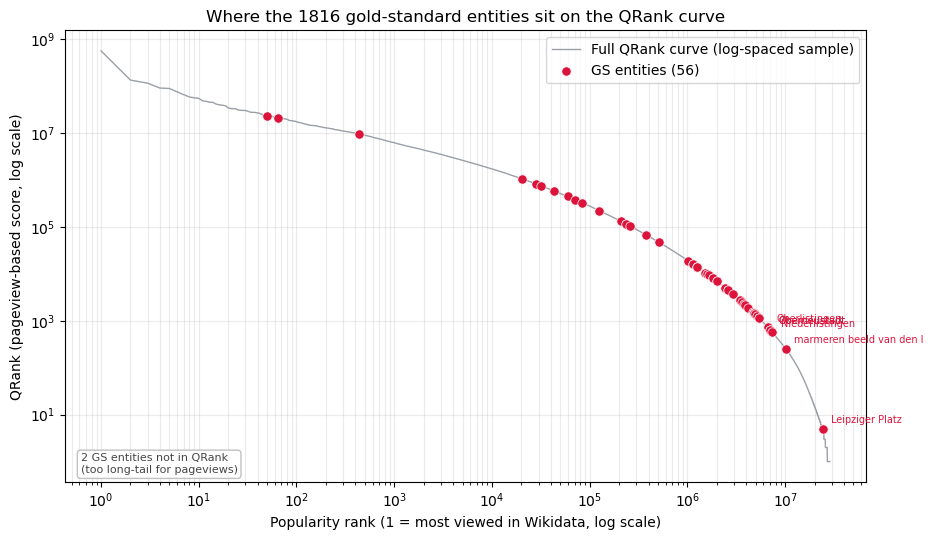

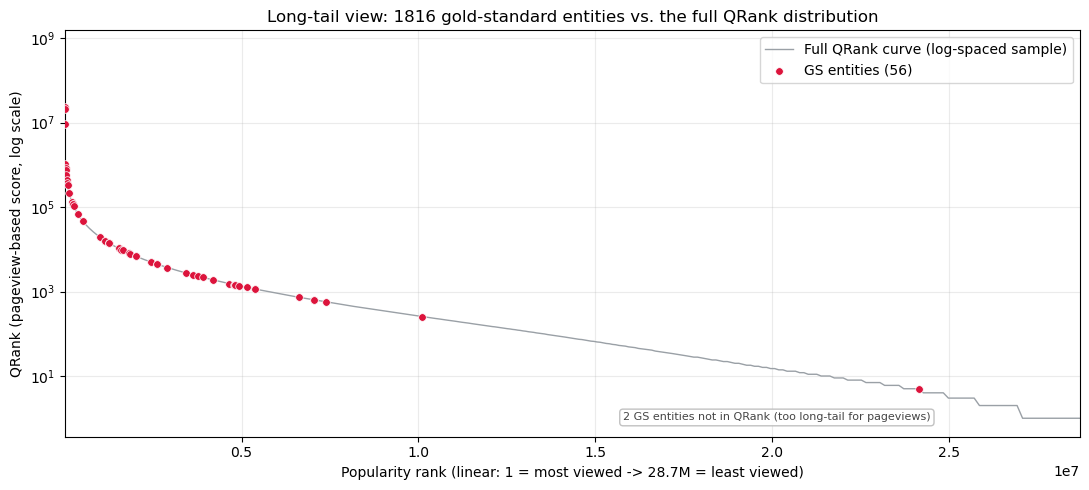

In [ ]:
# Build per-entity GS points (unique QID + span) with their rank on the curve.
gs_rows = []
for _, e in ent.iterrows():
    q = e.wikidata_qid
    if q in gs_match:
        r, qr = gs_match[q]
        gs_rows.append((r, qr, e.text, e.label, e.wikidata_label, q, e.n_mentions))
gs_df = pd.DataFrame(gs_rows, columns=['rank', 'QRank', 'text', 'label', 'wikidata_label', 'qid', 'n_mentions'])

n_unmatched = int((~ent.in_qrank).sum())
med_rank = gs_df['rank'].median() if len(gs_df) else np.nan
print(f'Matched GS entities plotted : {len(gs_df)}')
print(f'Unmatched (not in QRank)    : {n_unmatched}  (no rank -> shown as a count, off-curve)')
if len(gs_df):
    print(f'GS median popularity rank  : {med_rank:,.0f} / {N_total:,}  '
          f'(top {100*med_rank/N_total:.1f}% of Wikidata by pageviews)')
    print('\nMost long-tail matched GS entities:')
    print(gs_df.sort_values('rank', ascending=False)
             [['rank','QRank','wikidata_label','text','label','qid']]
             .head(10).to_string(index=False))

# ---- Figure 1: log-log curve (now covers the head too, thanks to log-spaced sampling) ----
fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.loglog(curve_rank, curve_qrank, lw=1.0, color='#9aa0a6',
          label='Full QRank curve (log-spaced sample)')
ax.scatter(gs_df['rank'], gs_df['QRank'], color='crimson', s=45,
           zorder=5, edgecolor='white', linewidth=0.5, label=f'GS entities ({len(gs_df)})')

# label the tail-most matched entities (prefer the Wikidata label, fall back to the span text)
if len(gs_df):
    tail = gs_df.sort_values('rank', ascending=False).head(6)
    for _, t in tail.iterrows():
        nm = t.wikidata_label if t.wikidata_label else t.text
        ax.annotate(nm[:24], (t['rank'], t['QRank']),
                    textcoords='offset points', xytext=(6, 4), fontsize=7, color='crimson')

ax.set_xlabel('Popularity rank (1 = most viewed in Wikidata, log scale)')
ax.set_ylabel('QRank (pageview-based score, log scale)')
ax.set_title('Where the 1816 gold-standard entities sit on the QRank curve')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='upper right')
ax.text(0.02, 0.02, f'{n_unmatched} GS entities not in QRank\n(too long-tail for pageviews)',
        transform=ax.transAxes, fontsize=8, color='#444',
        bbox=dict(boxstyle='round', fc='white', ec='#bbb', alpha=0.9))
plt.tight_layout()
fig.savefig(QRANK_DIR / 'qrank_full_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- Figure 2: traditional long-tail view (linear x-axis so the tail stretches right) ----
fig, ax = plt.subplots(figsize=(11, 5.0))
ax.plot(curve_rank, curve_qrank, lw=1.0, color='#9aa0a6',
        label='Full QRank curve (log-spaced sample)')
ax.scatter(gs_df['rank'], gs_df['QRank'], color='crimson', s=30,
           zorder=5, edgecolor='white', linewidth=0.5, label=f'GS entities ({len(gs_df)})')
ax.set_xscale('linear')          # linear rank: head is a cliff on the left, tail stretches right
ax.set_yscale('log')             # keep y log so the head and flat tail are both readable
ax.set_xlim(1, N_total)
ax.set_xlabel('Popularity rank (linear: 1 = most viewed -> 28.7M = least viewed)')
ax.set_ylabel('QRank (pageview-based score, log scale)')
ax.set_title('Long-tail view: EL gold-standard entities vs. the full QRank distribution')
ax.grid(True, which='both', alpha=0.25)
ax.legend(loc='upper right')
ax.text(0.55, 0.04, f'{n_unmatched} GS entities not in QRank (too long-tail for pageviews)',
        transform=ax.transAxes, fontsize=8, color='#444',
        bbox=dict(boxstyle='round', fc='white', ec='#bbb', alpha=0.9))
plt.tight_layout()
fig.savefig(QRANK_DIR / 'qrank_linear_longtail.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. How long-tail is the set?

QRank is heavily right-skewed (a few global-fame entities vs. a long flat tail). Summarise on a **log10** scale and bucket into head / mid / tail.

In [37]:
qr = ent.QRank.astype(int)
with np.errstate(divide='ignore'):
    log_qr = np.where(qr > 0, np.log10(qr), np.nan)

print('QRank summary (unique entities, unmatched -> 0):')
print(ent.QRank.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_string())
print(f'\nlog10(QRank) summary (only matched entities):')
print(pd.Series(log_qr[~np.isnan(log_qr)]).describe(percentiles=[.1,.25,.5,.75,.9]).to_string())

# buckets on log10 scale; 0 = not in dump
def bucket(v):
    if np.isnan(v): return 'tail (not in QRank)'
    if v < 4:      return 'tail (<1e4)'
    if v < 5:      return 'mid  (1e4-1e5)'
    if v < 6:      return 'mid  (1e5-1e6)'
    if v < 7:      return 'head (1e6-1e7)'
    return 'head (>=1e7)'
ent['longtail_bucket'] = [bucket(v) for v in log_qr]
print('\nEntities per bucket:')
print(ent.longtail_bucket.value_counts().to_string())

QRank summary (unique entities, unmatched -> 0):
count              58.0
mean     1019070.913793
std      4219112.082497
min                 0.0
10%               633.0
25%              1440.5
50%              7397.5
75%             95095.5
90%            632755.8
95%           2325200.7
99%         21932576.55
max          23409894.0

log10(QRank) summary (only matched entities):
count    56.000000
mean      4.130518
std       1.269373
min       0.698970
10%       2.959709
25%       3.181940
50%       3.900257
75%       5.030454
90%       5.819368
max       7.369399

Entities per bucket:
longtail_bucket
tail (<1e4)            31
mid  (1e5-1e6)         11
mid  (1e4-1e5)         10
head (>=1e7)            2
head (1e6-1e7)          2
tail (not in QRank)     2


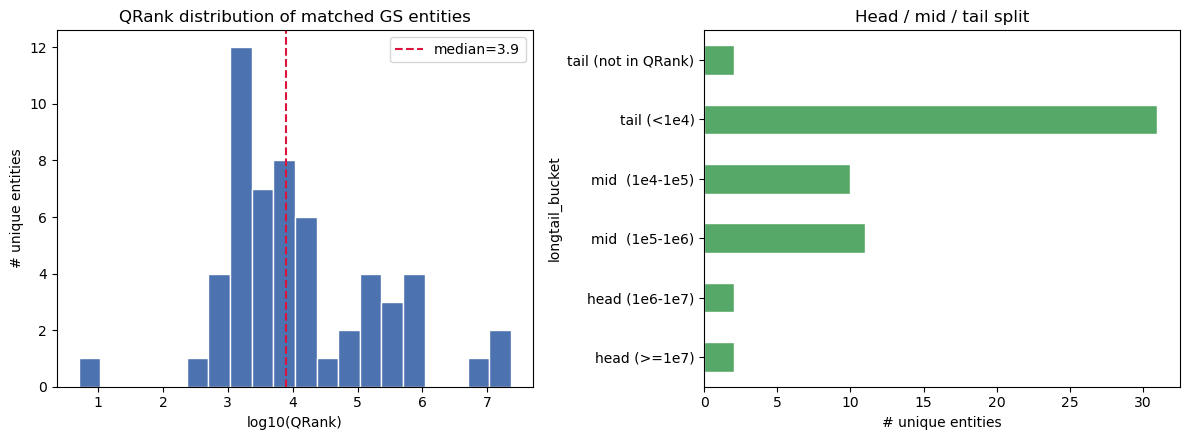

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(log_qr[~np.isnan(log_qr)], bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('log10(QRank)')
axes[0].set_ylabel('# unique entities')
axes[0].set_title('QRank distribution of matched GS entities')
axes[0].axvline(np.nanmedian(log_qr), color='crimson', ls='--', label=f'median={np.nanmedian(log_qr):.1f}')
axes[0].legend()

ent.longtail_bucket.value_counts().reindex(
    ['tail (not in QRank)','tail (<1e4)','mid  (1e4-1e5)','mid  (1e5-1e6)','head (1e6-1e7)','head (>=1e7)']
).fillna(0).plot.barh(ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_xlabel('# unique entities')
axes[1].set_title('Head / mid / tail split')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(QRANK_DIR / 'qrank_longtail.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Takeaways

- `1816_qrank_matched.csv` — every gold annotation with its entity span, label, QID, Wikidata label, and QRank.
- `1816_qrank_per_entity.csv` — one row per (QID, span, label) (de-duplicated by surface form).
- `qid_labels.json` — cached Wikidata labels for matched QIDs (nl preferred).
- `qrank_full_curve.png` — full QRank distribution (log-log) with GS entities plotted at their popularity rank.
- `qrank_linear_longtail.png` — long-tail view (linear x-axis) of the same distribution.
- `qrank_longtail.png` — GS distribution + head/mid/tail bucketing.

A high share of entities in the **tail** (low QRank, or not in the dump at all) confirms that this 1816 Dutch travelogue corpus is long-tail — exactly the regime where generic KB popularity priors (incl. most entity-linking candidate rankers) are weakest, motivating the LLM-based reranking/selection used elsewhere in this pipeline.